In [1]:
import sys
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import cm
import matplotlib as mp
# import gaia_tools as gt
import scipy
from scipy.ndimage import gaussian_filter
import astropy.units as u
from astropy.coordinates import SkyCoord
import math
import h5py
# import healpy as hp
import pykdgrav3_utils
from pykdgrav3_utils import units
un = units.units(1, 600., verbose=True)
import healpy as hp
from healpy.newvisufunc import projview, newprojplot
from matplotlib.projections.geo import GeoAxes
# import plotly.graph_objects as go
from matplotlib import colors

sys.path.append('/home/dnurme/linux_env/Thesis/My_thesis/Modules/')
from mock_wake import generate_mock_wake
from rotation_funcs import rotate, angle_finder, rz, ry, rx
from misc import plot_OD_gaussian, overdensity, resultant_OD_gaussian 

# plot_OD_gaussian_interactive, plot_gaussian_interactive

dMsolUnit = 1.000000e+00
dKpcUnit = 6.000000e+02
dGasConst =  1150890.1952769116
dErgPerGmUnit =  71.68174956254887
dGmPerCcUnit =  3.1333829769061664e-40
dSecUnit =  2.1867420491060357e+23
dKmPerSecUnit =  8.466507518602276e-05
dComovingGmPerCcUnit =  3.1333829769061664e-40


In [2]:
file1 = '/home/dnurme/linux_env/Data/dm_sim.00001.0'

def load_snap_file(path, part_type='PartType1', is_print = False):

    snap_file = h5py.File(path, 'r')
    part_data = snap_file[part_type]

    if(is_print):
        print(f'Loading snapshot: {path.split("/")[-1]}')
        print(f'Selected species: {part_type}')
        print(f'Snap file keys: {snap_file.keys()}')
        print(f'Part type keys: {part_data.keys()}')

    return part_data

In [3]:
snap_stars1 = load_snap_file(file1, part_type='PartType4', is_print=True)
star_coord1 = snap_stars1['Coordinates'][:]*un.dKpcUnit

x1 = star_coord1[:,0]
y1 = star_coord1[:,1]
z1 = star_coord1[:,2]

Loading snapshot: dm_sim.00001.0
Selected species: PartType4
Snap file keys: <KeysViewHDF5 ['Cosmology', 'Header', 'Parameters', 'PartType1', 'PartType4', 'Units']>
Part type keys: <KeysViewHDF5 ['Coordinates', 'GroupID', 'Masses', 'ParticleIDs', 'Potential', 'Softening', 'StellarFormationTime', 'Velocities']>


In [4]:
file = '/home/dnurme/linux_env/Data/pos_stars_Plummer_LMC.npy'
data = np.load(file)
x_plum = data[:,0]
y_plum = data[:,1]
z_plum = data[:,2]

star_coord2 = np.array([x_plum, y_plum, z_plum]).T

x2 = star_coord2[:,0]
y2 = star_coord2[:,1]
z2 = star_coord2[:,2]

In [5]:
# print(star_coord1.shape)
# print(star_coord2.shape)


In [6]:
# fig, ax = plt.subplots(figsize=(10, 10))
# plt.hist2d(star_coord3[:,0], star_coord3[:,1], bins=(300, 300), cmap = 'seismic', range=[[-300, 300], [-300, 300]])

In [7]:
# fig, axs = plt.subplots(2, 2, figsize=(12, 12))
# fig.suptitle('Difference plot between Plummer and Hernquist')

# axs[0, 0].hist2d(star_coord1[:,0], star_coord1[:,1], bins=(300, 300), cmap = 'viridis')

# axs[0,0].set_title('Hernquist')
# axs[0,0].set_xlabel('x [kpc]')
# axs[0,0].set_ylabel('y [kpc]')
# axs[0,0].set_xlim(-300, 300)
# axs[0,0].set_ylim(-300, 300)



# axs[0,1].hist2d(star_coord2[:,0], star_coord2[:,1], bins=(300, 300), cmap = 'viridis')

# axs[0,1].set_title('Plummer')
# axs[0,1].set_xlabel('x [kpc]')
# axs[0,1].set_ylabel('y [kpc]')
# axs[0,1].set_xlim(-300, 300)
# axs[0,1].set_ylim(-300, 300)

# axs[1, 0].hist2d(star_coord3[:,0], star_coord3[:,1], bins=(300, 300), cmap = 'viridis')

# axs[1,0].set_title('Difference')
# axs[1,0].set_xlabel('x [kpc]')
# axs[1,0].set_ylabel('y [kpc]')
# axs[1,0].set_xlim(-300, 300)
# axs[1,0].set_ylim(-300, 300)

(<Figure size 1800x600 with 6 Axes>,
 array([<Axes: title={'center': 'Hernquist Overdensity'}>,
        <Axes: title={'center': 'Plummer Overdensity'}>,
        <Axes: title={'center': 'Resultant Overdensity'}>], dtype=object))

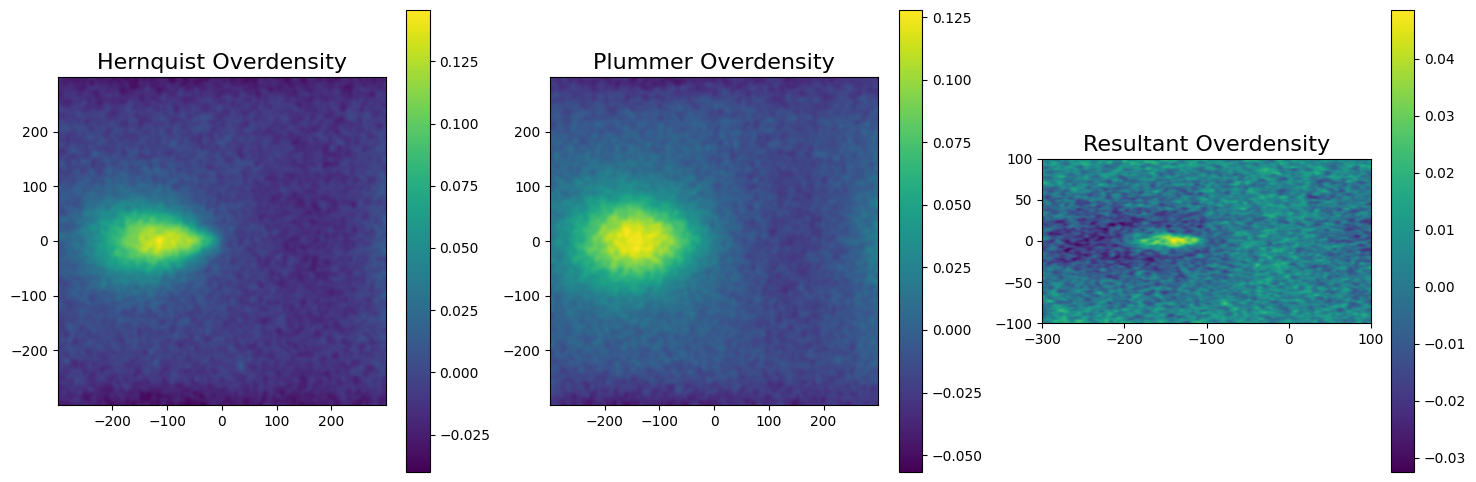

In [8]:
resultant_OD_gaussian(star_coord1, star_coord2, (300, 300), 2, "Hernquist", "Plummer")